In [68]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

os.makedirs("images",exist_ok=True)
df = pd.read_csv("all_data.csv")
df.rename(columns={"Life expectancy at birth (years)": "Life Expectancy"}, inplace=True)
print(df.head())

  Country  Year  Life Expectancy           GDP
0   Chile  2000             77.3  7.786093e+10
1   Chile  2001             77.3  7.097992e+10
2   Chile  2002             77.8  6.973681e+10
3   Chile  2003             77.9  7.564346e+10
4   Chile  2004             78.0  9.921039e+10


In [69]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          96 non-null     object 
 1   Year             96 non-null     int64  
 2   Life Expectancy  96 non-null     float64
 3   GDP              96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB
None


In [70]:
df.describe()

,Year,Life Expectancy,GDP
count,96.000000,96.000000,9.600000e+01
mean,2007.500000,72.789583,3.880499e+12
std,4.633971,10.672882,5.197561e+12
min,2000.000000,44.300000,4.415703e+09
25%,2003.750000,74.475000,1.733018e+11
50%,2007.500000,76.750000,1.280220e+12
75%,2011.250000,78.900000,4.067510e+12
max,2015.000000,81.000000,1.810000e+13


In [71]:

print(df.Country.unique())
print(df.Year.unique())
print(df.columns)
df.groupby('Country')[['GDP','Life Expectancy']].mean().sort_values(by='GDP', ascending=False)
df[df['Country']== 'China']

['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015]
Index(['Country', 'Year', 'Life Expectancy', 'GDP'], dtype='object')


,Country,Year,Life Expectancy,GDP
16,China,2000,71.7,1.211350e+12
17,China,2001,72.2,1.339400e+12
18,China,2002,72.7,1.470550e+12
19,China,2003,73.1,1.660290e+12
20,China,2004,73.5,1.955350e+12
21,China,2005,73.9,2.285970e+12
22,China,2006,74.2,2.752130e+12
23,China,2007,74.4,3.552180e+12
24,China,2008,74.5,4.598210e+12
25,China,2009,74.9,5.109950e+12


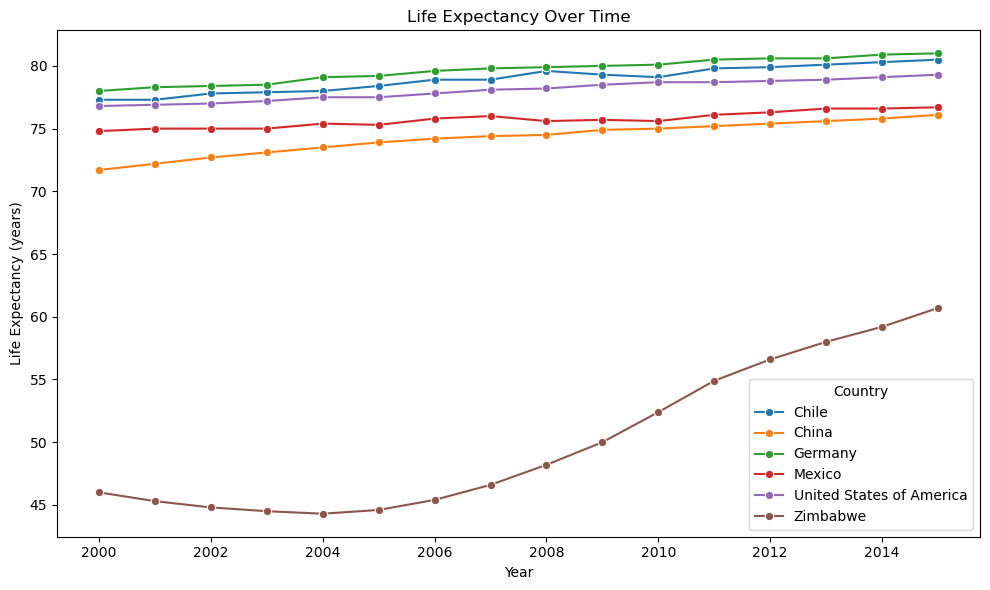

<Figure size 640x480 with 0 Axes>

In [72]:
plt.figure(figsize=(10,6))

sns.lineplot(data=df, x='Year', y='Life Expectancy', hue='Country', marker='o')
plt.title("Life Expectancy Over Time")
plt.ylabel("Life Expectancy (years)")
plt.xlabel("Year")
plt.legend(title="Country")

plt.tight_layout()
plt.savefig("images/life_expectancy_over_time.png", dpi=300)
plt.show()
plt.clf()

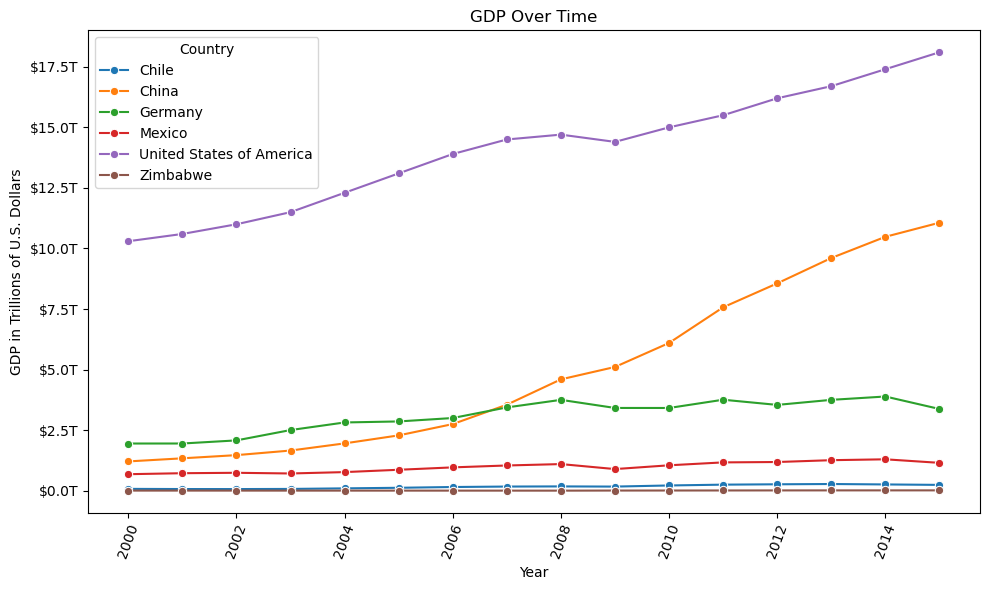

<Figure size 640x480 with 0 Axes>

In [73]:
# GDP plot

def trillions(x, pos):
    return '$%1.1fT' % (x * 1e-12)

formatter = FuncFormatter(trillions)

f, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='GDP', hue='Country', marker='o', ax=ax)
plt.xticks(rotation=70)
ax.yaxis.set_major_formatter(formatter)

plt.title("GDP Over Time")
plt.ylabel("GDP in Trillions of U.S. Dollars")
plt.xlabel("Year")
plt.legend(title="Country")

plt.tight_layout()
plt.savefig("images/gdp_over_time.png", dpi=300)
plt.show()
plt.clf()

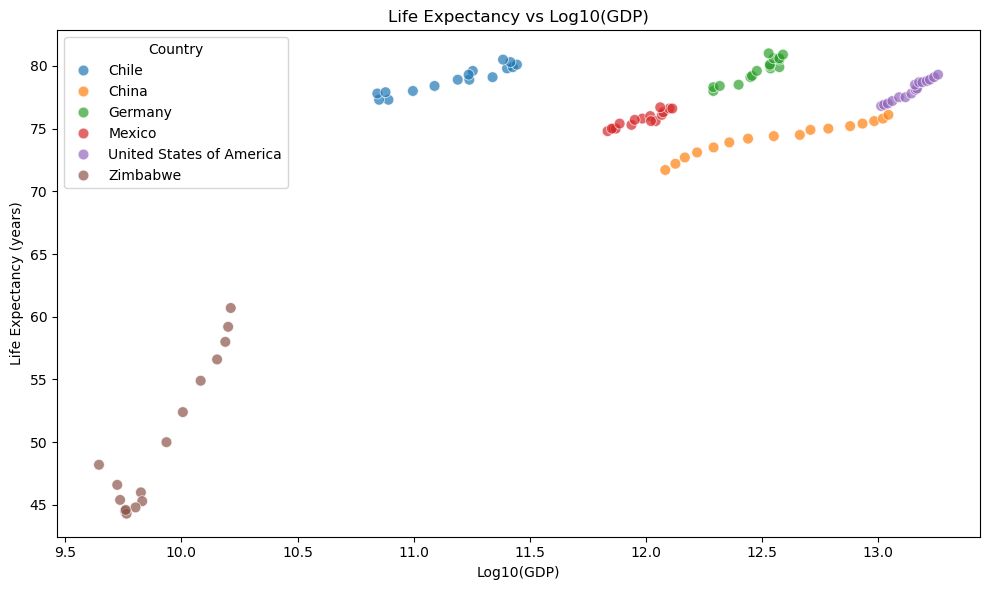

<Figure size 640x480 with 0 Axes>

In [74]:
df['log_GDP'] = np.log10(df['GDP'])
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='log_GDP',
    y='Life Expectancy',
    hue='Country',
    marker='o',
    alpha=0.7,
    s=60
)
#sns.regplot(data=df, x='GDP', y='Life Expectancy', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
#sns.lmplot(data=df, x='GDP', y='Life Expectancy', hue='Country', height=6, aspect=1.5, scatter_kws={'alpha':0.6})
#sns.heatmap(df[['GDP', 'Life Expectancy']].corr(), annot=True, cmap='coolwarm')
#df['log_GDP'] = np.log10(df['GDP'])
#sns.pairplot(df[['log_GDP','Life Expectancy','Country']], hue='Country')

plt.title("Life Expectancy vs Log10(GDP)")
plt.xlabel("Log10(GDP)")
plt.ylabel("Life Expectancy (years)")
plt.legend(title="Country")

plt.tight_layout()
plt.savefig("images/life_expectancy_vs_log_gdp.png", dpi=300)
plt.show()
plt.clf()

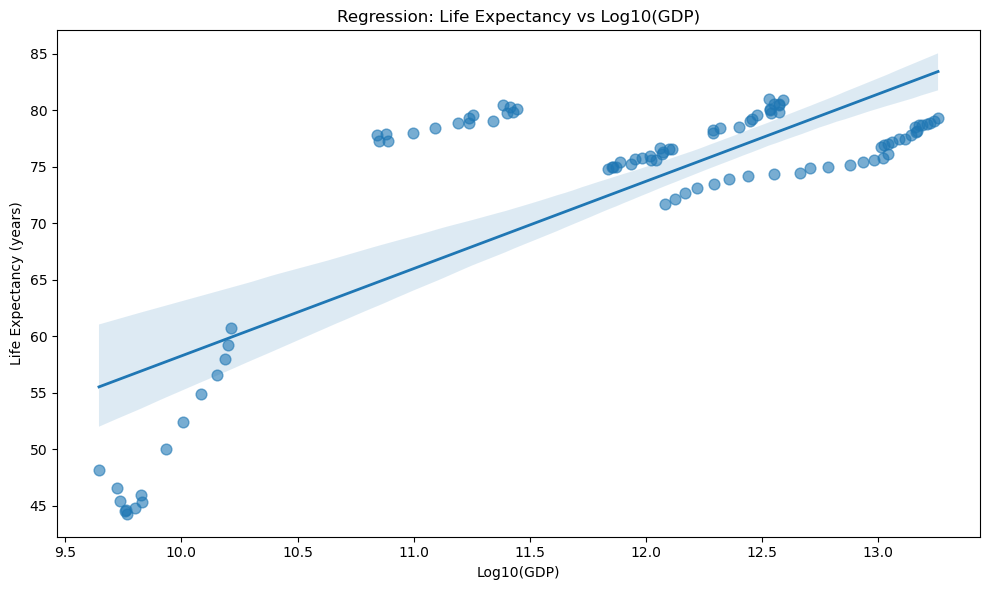

<Figure size 640x480 with 0 Axes>

In [75]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=df,
    x='log_GDP',
    y='Life Expectancy',
    scatter_kws={'alpha':0.6, 's':60},
    line_kws={'linewidth':2}
)
plt.title("Regression: Life Expectancy vs Log10(GDP)")
plt.xlabel("Log10(GDP)")
plt.ylabel("Life Expectancy (years)")

plt.tight_layout()
plt.savefig("images/regression_life_expectancy_vs_log_gdp.png", dpi=300)
plt.show()
plt.clf()

In [76]:
correlation = df[['GDP', 'Life Expectancy']].corr()
print("Correlation Matrix:")
print(correlation)

log_correlation = df[['log_GDP', 'Life Expectancy']].corr()
print("Correlation Matrix with log_GDP:")
print(log_correlation)

Correlation Matrix:
                      GDP  Life Expectancy
GDP              1.000000         0.343207
Life Expectancy  0.343207         1.000000
Correlation Matrix with log_GDP:
                  log_GDP  Life Expectancy
log_GDP          1.000000         0.787342
Life Expectancy  0.787342         1.000000


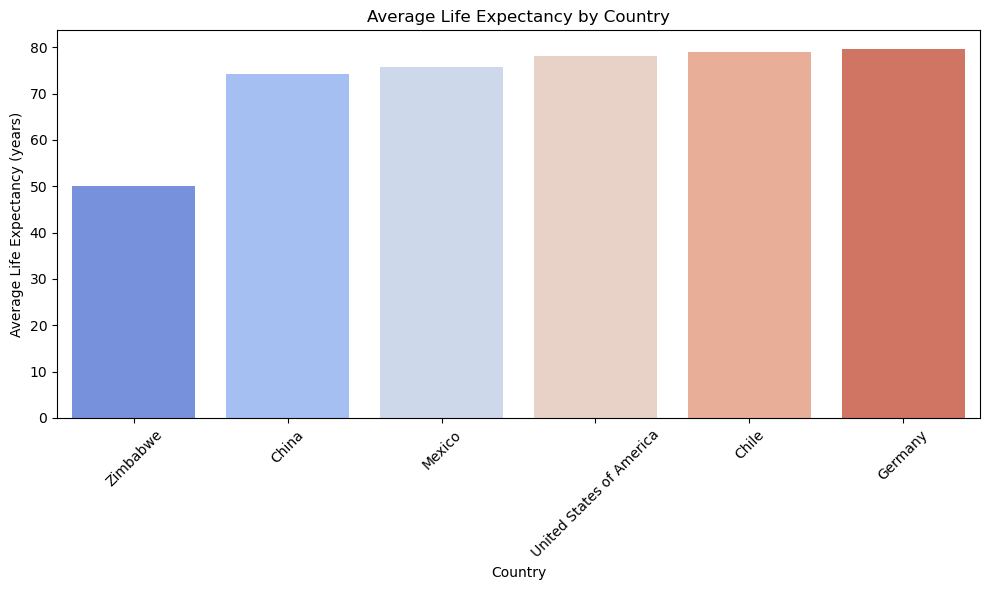

<Figure size 640x480 with 0 Axes>

In [77]:
avg_life = df.groupby('Country')['Life Expectancy'].mean().sort_values()

plt.figure(figsize=(10,6))
sns.barplot(
    x=avg_life.index,
    y=avg_life.values,
    hue=avg_life.index,
    palette='coolwarm',
    legend=False
)

plt.title("Average Life Expectancy by Country")
plt.xlabel("Country")
plt.ylabel("Average Life Expectancy (years)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("images/average_life_expectancy_by_country.png", dpi=300)
plt.show()
plt.clf()

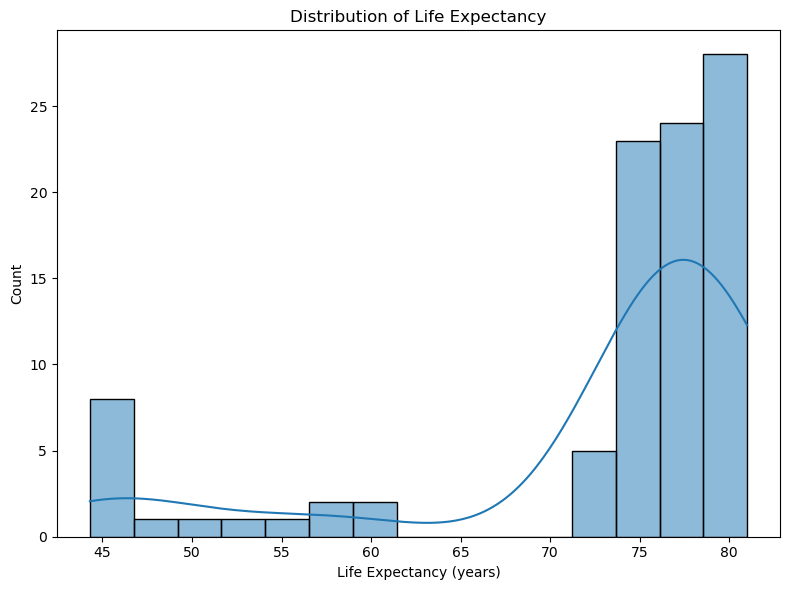

<Figure size 640x480 with 0 Axes>

In [78]:
plt.figure(figsize=(8,6))
sns.histplot(
    df['Life Expectancy'],
    bins=15,
    kde=True
)

plt.title("Distribution of Life Expectancy")
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("images/life_expectancy_distribution.png", dpi=300)
plt.show()
plt.clf()

/var/folders/3k/8jqmn82n6svbffzwftg71ybr0000gn/T/ipykernel_30297/2127206105.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


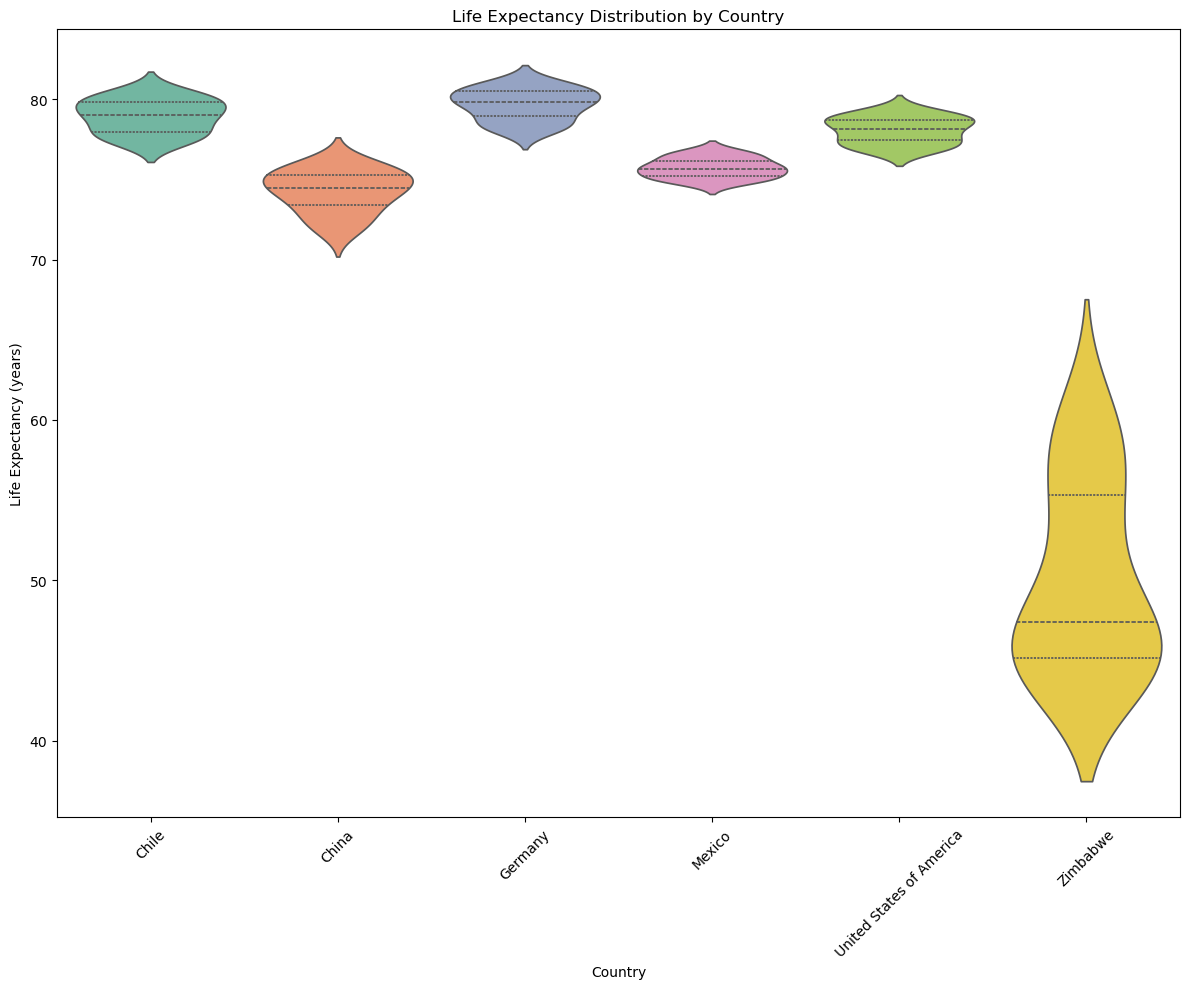

<Figure size 640x480 with 0 Axes>

In [79]:
plt.figure(figsize=(12, 10))

sns.violinplot(
    data=df,
    x='Country',
    y='Life Expectancy',
    palette='Set2',
    inner='quartile'
)

plt.title("Life Expectancy Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Life Expectancy (years)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("images/violin_life_expectancy_by_country.png", dpi=300)
plt.show()
plt.clf()

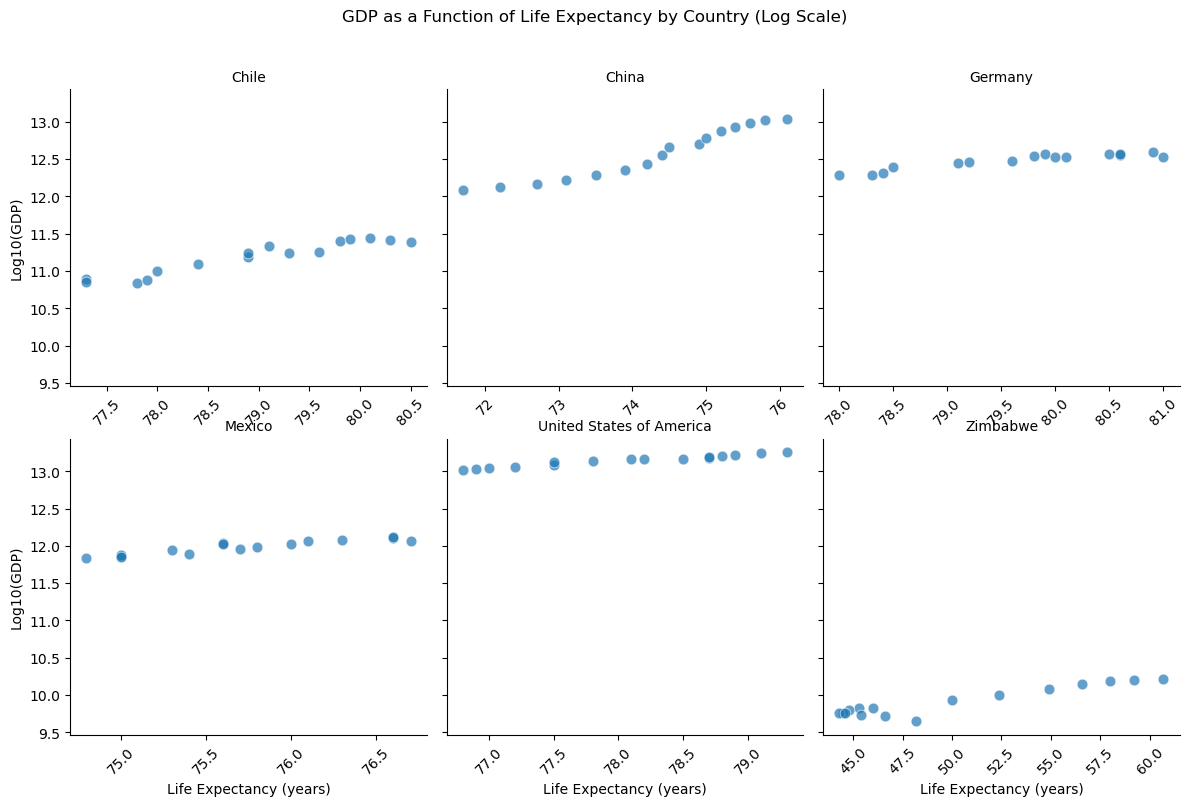

<Figure size 640x480 with 0 Axes>

In [85]:
df['log_GDP'] = np.log10(df['GDP'])

g = sns.FacetGrid(
    df,
    col="Country",
    col_wrap=3,
    height=4,
    sharex=False,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Life Expectancy",
    y="log_GDP",
    s=60,
    alpha=0.7
)

g.set_axis_labels("Life Expectancy (years)", "Log10(GDP)")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

g.figure.subplots_adjust(top=0.88)
g.figure.suptitle("GDP as a Function of Life Expectancy by Country (Log Scale)")
g.savefig("images/facet_scatter_log_gdp_vs_life_expectancy_by_country.png", dpi=300)
plt.show()
plt.clf()

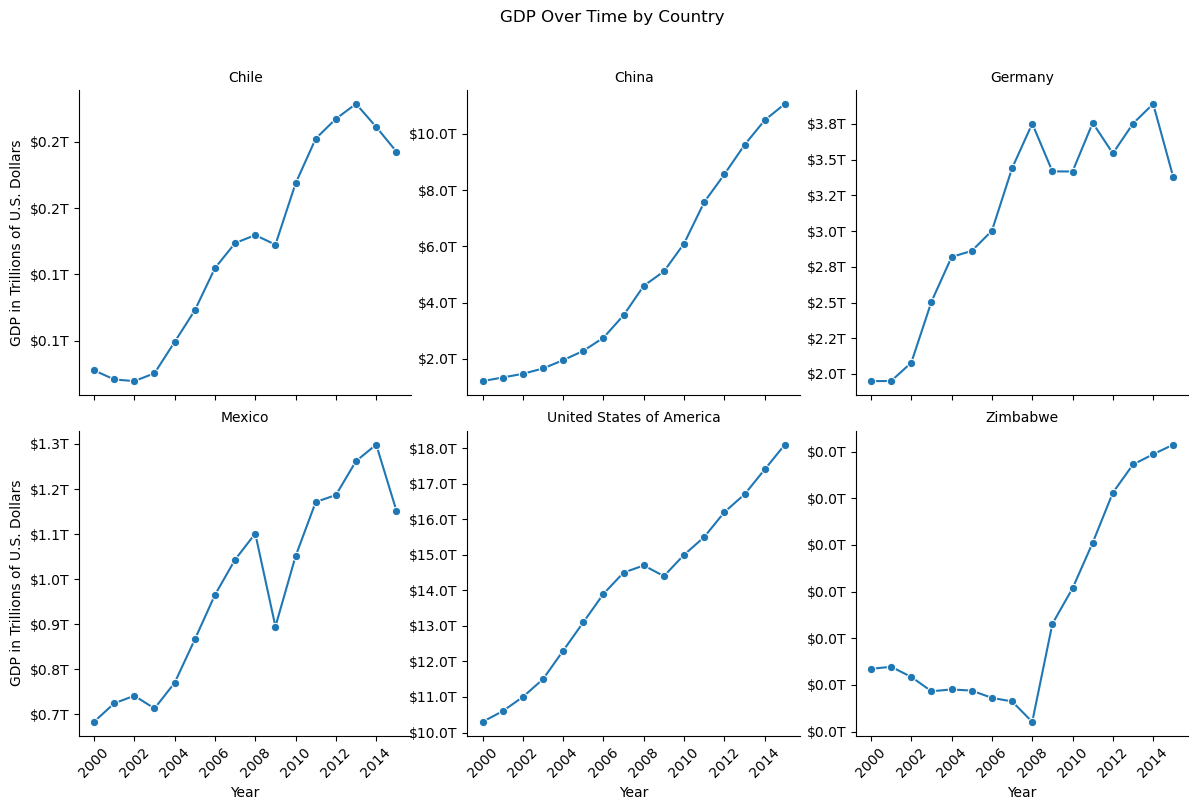

<Figure size 640x480 with 0 Axes>

In [84]:

def trillions(x, pos):
    return '$%1.1fT' % (x * 1e-12)

g = sns.FacetGrid(
    df,
    col="Country",
    col_wrap=3,
    height=4,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="Year",
    y="GDP",
    marker="o"
)

g.set_axis_labels("Year", "GDP in Trillions of U.S. Dollars")
g.set_titles("{col_name}")

years = sorted(df["Year"].unique())[::2]

for ax in g.axes.flat:
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(FuncFormatter(trillions))

g.figure.subplots_adjust(top=0.88)
g.figure.suptitle("GDP Over Time by Country")

g.savefig("images/facet_gdp_by_country.png", dpi=300)
plt.show()
plt.clf()